## Data Wrangling - Laptop Pricing


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("dark_background")

file_path='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv'

headers = ["Manufacturer","Category","Screen","GPU","OS","CPU_core","Screen_Size_inch","CPU_frequency","RAM_GB","Storage_GB_SSD","Weight_kg","Price"]

df = pd.read_csv(file_path, header=0, index_col=0)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Manufacturer    238 non-null    str    
 1   Category        238 non-null    int64  
 2   Screen          238 non-null    str    
 3   GPU             238 non-null    int64  
 4   OS              238 non-null    int64  
 5   CPU_core        238 non-null    int64  
 6   Screen_Size_cm  234 non-null    float64
 7   CPU_frequency   238 non-null    float64
 8   RAM_GB          238 non-null    int64  
 9   Storage_GB_SSD  238 non-null    int64  
 10  Weight_kg       233 non-null    float64
 11  Price           238 non-null    int64  
dtypes: float64(3), int64(7), str(2)
memory usage: 22.4 KB


In [17]:
df.head()

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


In [18]:
# rounding up the value to 2 decimal place for Screen_Size_cm

df["Screen_Size_cm"] = np.round(df["Screen_Size_cm"],2)
df.head()

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.60,978
1,Dell,3,Full HD,1,1,3,39.62,2.0,4,256,2.20,634
2,Dell,3,Full HD,1,1,7,39.62,2.7,8,256,2.20,946
3,Dell,4,IPS Panel,2,1,5,33.78,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.62,1.8,8,256,1.91,837


### Evaluate Dataset for Missing Data

In [19]:
# look for missing data
missing_data = df.isnull()

# for each column in the missing_data dataframe, check if that column has any True value (indicating NaN)
for column in missing_data.columns.values.tolist():
    if missing_data[column].any():
        print(missing_data[column].value_counts())
        print("")

# alternatively, we can check which collumns has missing data
missing_data.any()

Screen_Size_cm
False    234
True       4
Name: count, dtype: int64

Weight_kg
False    233
True       5
Name: count, dtype: int64



Manufacturer      False
Category          False
Screen            False
GPU               False
OS                False
CPU_core          False
Screen_Size_cm     True
CPU_frequency     False
RAM_GB            False
Storage_GB_SSD    False
Weight_kg          True
Price             False
dtype: bool

### Replace Missing Data with Mean value
* Missing values in attributes that have continuous data are best replaced using Mean value. 
* Missing values in attributes that have categorical data are best replaced using the most frequent value.

In [20]:
# check the data type of the missing data
df[["Screen_Size_cm","Weight_kg"]].dtypes

Screen_Size_cm    float64
Weight_kg         float64
dtype: object

In [21]:
# Missing values in attributes that have continuous data are best replaced using Mean value. 
avg_weight = df["Weight_kg"].astype("float").mean(axis=0)
df["Weight_kg"] = df["Weight_kg"].replace(np.nan, avg_weight)

# Missing values in attributes that have categorical data are best replaced using the most frequent value.
freq_screen = df["Screen_Size_cm"].value_counts().idxmax() # value with highest frequency
df["Screen_Size_cm"] = df["Screen_Size_cm"].replace(np.nan, freq_screen)

df[["Screen_Size_cm","Weight_kg"]]

,Screen_Size_cm,Weight_kg
0,35.56,1.60
1,39.62,2.20
2,39.62,2.20
3,33.78,1.22
4,39.62,1.91
...,...,...
233,35.56,1.70
234,33.78,1.20
235,30.48,1.36
236,39.62,2.40


In [22]:
df[["Screen_Size_cm","Weight_kg"]].isnull().any()

Screen_Size_cm    False
Weight_kg         False
dtype: bool

In [23]:
df.isnull().any()

Manufacturer      False
Category          False
Screen            False
GPU               False
OS                False
CPU_core          False
Screen_Size_cm    False
CPU_frequency     False
RAM_GB            False
Storage_GB_SSD    False
Weight_kg         False
Price             False
dtype: bool

### Fixing the Data Types
* use the .astype() to change the data types


Our dataset is already in its proper data types, so nothing to be done here.

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Manufacturer    238 non-null    str    
 1   Category        238 non-null    int64  
 2   Screen          238 non-null    str    
 3   GPU             238 non-null    int64  
 4   OS              238 non-null    int64  
 5   CPU_core        238 non-null    int64  
 6   Screen_Size_cm  238 non-null    float64
 7   CPU_frequency   238 non-null    float64
 8   RAM_GB          238 non-null    int64  
 9   Storage_GB_SSD  238 non-null    int64  
 10  Weight_kg       238 non-null    float64
 11  Price           238 non-null    int64  
dtypes: float64(3), int64(7), str(2)
memory usage: 22.4 KB


### Data Standardization

* The value of Screen_size and Weight needs to be in inch and pound respectively.

In [25]:
# 1 inch = 2.54 cm ; 1 kg = 2.205 pounds

df["Screen_Size_in"] = df["Screen_Size_cm"] / 2.54
df["Weight_lb"] = df["Weight_kg"] * 2.205

df.head()

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Screen_Size_in,Weight_lb
0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.60,978,14.000000,3.52800
1,Dell,3,Full HD,1,1,3,39.62,2.0,4,256,2.20,634,15.598425,4.85100
2,Dell,3,Full HD,1,1,7,39.62,2.7,8,256,2.20,946,15.598425,4.85100
3,Dell,4,IPS Panel,2,1,5,33.78,1.6,8,128,1.22,1244,13.299213,2.69010
4,HP,4,Full HD,2,1,7,39.62,1.8,8,256,1.91,837,15.598425,4.21155


### Data Normalization

* Often it is required to normalize a continuous data attribute.
* here, we need to normalize CPU_frequency attribute with respect to the max value.

In [26]:

# Normalizing CPU_frequency wrt to its max value
df['CPU_frequency'] = df['CPU_frequency']/df['CPU_frequency'].max()

df.head()

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Screen_Size_in,Weight_lb
0,Acer,4,IPS Panel,2,1,5,35.56,0.551724,8,256,1.60,978,14.000000,3.52800
1,Dell,3,Full HD,1,1,3,39.62,0.689655,4,256,2.20,634,15.598425,4.85100
2,Dell,3,Full HD,1,1,7,39.62,0.931034,8,256,2.20,946,15.598425,4.85100
3,Dell,4,IPS Panel,2,1,5,33.78,0.551724,8,128,1.22,1244,13.299213,2.69010
4,HP,4,Full HD,2,1,7,39.62,0.620690,8,256,1.91,837,15.598425,4.21155


### Binning
* Binning is a process of creating a categorical attribute which splits the values of a continuous data into a specified number of groups. 
* In this case, we need to create 3 bins for the attribute "Price". These bins would be named "Low", "Medium" and "High". The new attribute will be named "Price-binned".

In [27]:

bins = np.linspace(min(df["Price"]), max(df["Price"]), 4)  # 4 = number of dividers = number of required bins + 1
bins

group_names = ['Low','Medium','High'] # bin labels

df['Price-binned'] = pd.cut(df['Price'], bins, labels=group_names, include_lowest=True)
df[['Price','Price-binned']].head(20)

,Price,Price-binned
0,978,Low
1,634,Low
2,946,Low
3,1244,Low
4,837,Low
5,1016,Low
6,1117,Low
7,866,Low
8,812,Low
9,1068,Low


In [28]:
df['Price-binned'].value_counts()

Price-binned
Low       160
Medium     72
High        6
Name: count, dtype: int64

Text(0.5, 1.0, 'Price bins')

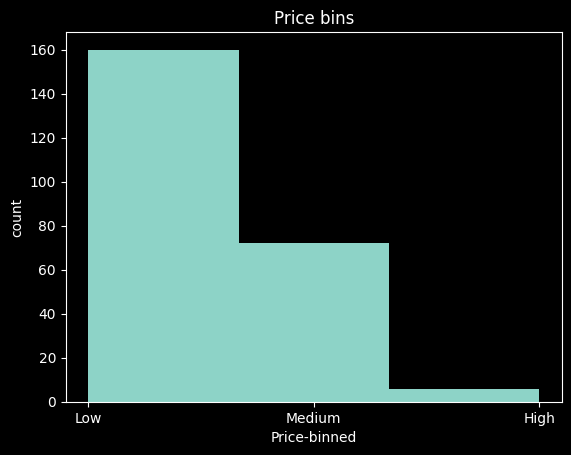

In [30]:
# Bins Visualization with histogram for the distribution of bins

plt.hist(df["Price-binned"], bins=3)  # draw historgram of attribute 'horsepower' with bins=3

plt.xlabel("Price-binned")
plt.ylabel("count")
plt.title("Price bins")

### Categorizing Data to Indicator variables

* Convert the "Screen" attribute of the dataset into 2 indicator variables, "Screen-IPS_panel" and "Screen-Full_HD". 


In [31]:

dummy1 = pd.get_dummies(df['Screen']) # returns a dataframe

# Each value in the Screen column is named base on its original value, e.g. IPS Panel renamed to Screen-IPS_panel
dummy1.rename(columns={'IPS Panel':'Screen-IPS_panel', 'Full HD':'Screen-Full_HD'}, inplace=True)
print(dummy1.head())

# append the above dataframes to the main dataframe along the column axis, df
df = pd.concat([df, dummy1], axis=1)
df.drop('Screen', axis=1, inplace=True)  # drop off the original 'aspiration' column

df.head()

   Screen-Full_HD  Screen-IPS_panel
0           False              True
1            True             False
2            True             False
3           False              True
4            True             False


,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Screen_Size_in,Weight_lb,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,35.56,0.551724,8,256,1.60,978,14.000000,3.52800,Low,False,True
1,Dell,3,1,1,3,39.62,0.689655,4,256,2.20,634,15.598425,4.85100,Low,True,False
2,Dell,3,1,1,7,39.62,0.931034,8,256,2.20,946,15.598425,4.85100,Low,True,False
3,Dell,4,2,1,5,33.78,0.551724,8,128,1.22,1244,13.299213,2.69010,Low,False,True
4,HP,4,2,1,7,39.62,0.620690,8,256,1.91,837,15.598425,4.21155,Low,True,False


In [32]:
df.to_csv('clean_df_Laptop.csv')

In [33]:
df.describe()

,Category,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Screen_Size_in,Weight_lb
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
mean,3.205882,2.151261,1.058824,5.630252,37.307395,0.813822,7.882353,245.781513,1.862232,1462.344538,14.687951,4.106221
std,0.776533,0.638282,0.235790,1.241787,2.960595,0.141860,2.482603,34.765316,0.489090,574.607699,1.165589,1.078442
min,1.000000,1.000000,1.000000,3.000000,30.480000,0.413793,4.000000,128.000000,0.810000,527.000000,12.000000,1.786050
25%,3.000000,2.000000,1.000000,5.000000,35.560000,0.689655,8.000000,256.000000,1.472500,1066.500000,14.000000,3.246863
50%,3.000000,2.000000,1.000000,5.000000,38.100000,0.862069,8.000000,256.000000,1.862232,1333.000000,15.000000,4.106221
75%,4.000000,3.000000,1.000000,7.000000,39.620000,0.931034,8.000000,256.000000,2.200000,1777.000000,15.598425,4.851000
max,5.000000,3.000000,2.000000,7.000000,43.940000,1.000000,16.000000,256.000000,3.600000,3810.000000,17.299213,7.938000
